# Mohajer m vs NDCG@10 on TREC-COVID

Sweep the Mohajer ranker's `m` parameter and measure how it affects NDCG@10 on the TREC-COVID reranking matrix. All runs reuse the same seed and cached data so only the sampling budget controlled by `m` is changing.


In [1]:
from typing import Sequence

import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

from ireranker.data.loaders import load_beir_dataset
from ireranker.evaluation.beir import evaluate_rankers_beir
from ireranker.rankers import get_ranker

plt.style.use('ggplot')


2025-11-25 18:28:18.548 | INFO     | ireranker.config:<module>:14 - PROJ_ROOT path is: /home/jerefigo/Documents/UdeSA/Procesamiento_del_Lenguaje_Natural/IReranker


In [2]:
DATASET = 'fiqa'
SEEDS = [42]
K_VALUES = [10]
M_VALUES = np.linspace(0, 2, 100)

dataset = load_beir_dataset(DATASET, split='test')
print(f'Loaded {DATASET} with {len(dataset.tasks)} queries.')
print(f'Running {len(SEEDS)} seeds: {SEEDS}')


/home/jerefigo/.local/lib/python3.10/site-packages/beir/util.py:11: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from tqdm.autonotebook import tqdm


2025-11-25 18:28:19.675 | INFO     | ireranker.data.loaders:_download_beir_once:79 - Using existing BEIR dataset at: /home/jerefigo/Documents/UdeSA/Procesamiento_del_Lenguaje_Natural/IReranker/data/external/beir/fiqa
2025-11-25 18:28:51.290 | INFO     | ireranker.data.loaders:_load_rerank_matrix:151 - Loaded rerank matrix for fiqa/test (queries: 648)
2025-11-25 18:28:51.300 | INFO     | ireranker.data.loaders:load_beir_dataset:229 - Using rerank matrix for 648 queries in fiqa/test
Loaded fiqa with 648 queries.
Running 1 seeds: [42]


In [3]:
def evaluate_m_values(m_values: Sequence[float], seeds: Sequence[int]) -> pd.DataFrame:
    rows = []
    for seed in seeds:
        for m in m_values:
            ranker = get_ranker('mohajer', seed=seed)
            ranker.m = m
            ranker.set_dataset(DATASET, split='test')
            result = evaluate_rankers_beir([ranker], dataset, K_VALUES, seed=seed)[0]
            rows.append({
                'seed': seed,
                'm': m,
                'NDCG@10': float(result['NDCG']),
                'MAP@10': float(result['MAP']),
                'Recall@10': float(result['Recall']),
                'P@10': float(result['Precision']),
                'Comparisons': int(result['Comparisons']),
                'NDCG_per_comp': float(result['NDCG_per_comp']),
            })
    return pd.DataFrame(rows).sort_values(['seed', 'm']).reset_index(drop=True)

m_sweep_df = evaluate_m_values(M_VALUES, SEEDS)
m_sweep_df


Evaluating rankers: 100%|██████████| 1/1 [00:02<00:00,  2.02s/it]


,seed,m,NDCG@10,MAP@10,Recall@10,P@10,Comparisons,NDCG_per_comp
0,42,0.000000,0.04918,0.02905,0.09283,0.01619,0,0.000000
1,42,0.020202,0.05311,0.03026,0.10625,0.01762,3024,0.000018
2,42,0.040404,0.05883,0.03489,0.11079,0.01906,6181,0.000010
3,42,0.060606,0.06413,0.03985,0.12008,0.01947,9396,0.000007
4,42,0.080808,0.06683,0.04018,0.12637,0.02152,12791,0.000005
...,...,...,...,...,...,...,...,...
95,42,1.919192,0.42628,0.34336,0.59026,0.09713,298473,0.000001
96,42,1.939394,0.42041,0.33781,0.59106,0.09590,301933,0.000001
97,42,1.959596,0.42459,0.33263,0.62508,0.10102,305695,0.000001
98,42,1.979798,0.40965,0.32006,0.60052,0.09898,309019,0.000001


In [4]:
best_overall = m_sweep_df.loc[m_sweep_df['NDCG@10'].idxmax()]
mean_by_m = m_sweep_df.groupby('m')['NDCG@10'].mean().reset_index().sort_values('NDCG@10', ascending=False)
best_mean = mean_by_m.iloc[0]
best_overall, best_mean


(seed                 42.000000
 m                     1.797980
 NDCG@10               0.448110
 MAP@10                0.361750
 Recall@10             0.623470
 P@10                  0.102050
 Comparisons      278628.000000
 NDCG_per_comp         0.000002
 Name: 89, dtype: float64,
 m          1.79798
 NDCG@10    0.44811
 Name: 89, dtype: float64)

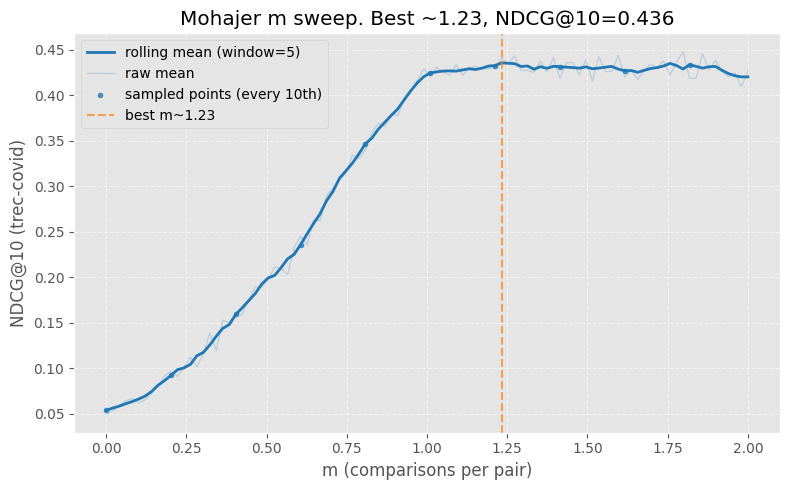

In [6]:
mean_by_m = m_sweep_df.groupby('m')['NDCG@10'].agg(['mean', 'std']).reset_index()
mean_by_m = mean_by_m.sort_values('m')
smoothed = mean_by_m['mean'].rolling(window=5, center=True, min_periods=1).mean()

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(mean_by_m['m'], smoothed, linewidth=2, color='tab:blue', label='rolling mean (window=5)')
ax.plot(mean_by_m['m'], mean_by_m['mean'], color='tab:blue', alpha=0.2, linewidth=1, label='raw mean')
ax.scatter(mean_by_m['m'][::10], smoothed.iloc[::10], color='tab:blue', s=12, alpha=0.8, label='sampled points (every 10th)')

if mean_by_m['std'].notna().any():
    lower = smoothed - mean_by_m['std']
    upper = smoothed + mean_by_m['std']
    ax.fill_between(mean_by_m['m'], lower, upper, color='tab:blue', alpha=0.08, label='+/- 1 std (rolling)')

best_row = smoothed.idxmax()
best_m = float(mean_by_m.loc[best_row, 'm'])
best_ndcg = float(smoothed.loc[best_row])
ax.axvline(best_m, color='tab:orange', linestyle='--', alpha=0.7, label=f'best m~{best_m:.2f}')

ax.set_xlabel('m (comparisons per pair)')
ax.set_ylabel('NDCG@10 (trec-covid)')
ax.set_title(f'Mohajer m sweep. Best ~{best_m:.2f}, NDCG@10={best_ndcg:.3f}')
ax.grid(True, linestyle='--', alpha=0.5)
ax.legend()
plt.tight_layout()
plt.show()


- Reuse the cached rerank matrix under `data/external/reranking-matrices` and the BEIR dataset cache under `data/external/beir`.
- Adjust `M_VALUES` to try different sampling budgets or add finer granularity.
- Keep the seed fixed when you want to compare only the effect of `m`; change it to check robustness across random draws.
